## Travel Data EDA Workshop

A hands-on, interactive notebook covering the full **Exploratory Data Analysis (EDA)** workflow — from generating a raw dataset with missing values, through cleaning, to univariate, bivariate, and visual analysis.

**How to use this notebook:**
- Read each section and run the code cells in order (`Shift + Enter`).
- Whenever you see a **🤔 Question** cell, try answering it yourself in the empty code/markdown cell below it *before* looking at the **✅ Solution**.
- Solutions are provided immediately after each question so you can check your reasoning.

**Dataset:** a synthetic travel bookings dataset — **1,829 rows × 10 columns** — generated in Section 1, with realistic missing values injected so we have something genuine to clean.

---


## 1. Setup & Data Generation

We'll first import our libraries, then generate a synthetic **travel bookings** dataset. Since this is simulated data, we control exactly what goes into it — including realistic missing values — which makes it perfect for practicing EDA end-to-end.

### Columns we'll create (10 total)

| # | Column | Type | Description |
|---|--------|------|-------------|
| 1 | `booking_id` | int | Unique booking identifier |
| 2 | `destination` | category | Travel destination city |
| 3 | `travel_month` | category | Month the trip took place |
| 4 | `trip_duration_days` | int | Length of the trip in days |
| 5 | `traveler_age` | float | Age of the primary traveler *(has missing values)* |
| 6 | `num_travelers` | int | Number of people on the booking |
| 7 | `transport_mode` | category | Flight, Train, Bus, or Car |
| 8 | `trip_cost_usd` | float | Total trip cost in USD *(has missing values)* |
| 9 | `hotel_rating` | float | Hotel star rating, 1.0–5.0 *(has missing values)* |
| 10 | `satisfaction_score` | float | Post-trip satisfaction, 1–5 *(has missing values)* |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)

# Visual defaults
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries loaded ✔")

Libraries loaded ✔


In [2]:
N_ROWS = 1829

destinations = ["Paris", "Bali", "New York", "Tokyo", "Rome", "Cape Town",
                "Sydney", "Bangkok", "Barcelona", "Dubai", "Lisbon", "Prague"]
dest_weights = [0.14, 0.12, 0.11, 0.10, 0.09, 0.06,
                0.08, 0.09, 0.07, 0.06, 0.04, 0.04]

months = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]

transport_modes = ["Flight", "Train", "Bus", "Car"]
transport_weights = [0.55, 0.20, 0.15, 0.10]

# --- Core columns ---
booking_id = np.arange(100001, 100001 + N_ROWS)
destination = np.random.choice(destinations, size=N_ROWS, p=dest_weights)
travel_month = np.random.choice(months, size=N_ROWS)
trip_duration_days = np.random.randint(2, 21, size=N_ROWS)
num_travelers = np.random.choice([1, 2, 3, 4, 5, 6], size=N_ROWS,
                                  p=[0.30, 0.35, 0.15, 0.10, 0.06, 0.04])
transport_mode = np.random.choice(transport_modes, size=N_ROWS, p=transport_weights)

# Age: roughly normal, clipped to a realistic travel-age range
traveler_age = np.random.normal(loc=38, scale=12, size=N_ROWS).clip(18, 80).round(0)

# Cost: scales with duration & travelers, plus noise
base_cost = 120 * trip_duration_days * (1 + 0.6 * (num_travelers - 1))
trip_cost_usd = (base_cost * np.random.uniform(0.8, 1.3, size=N_ROWS)).round(2)

# Hotel rating: skewed toward 3-5 stars
hotel_rating = np.random.choice([1.0, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
                                 size=N_ROWS,
                                 p=[0.02, 0.04, 0.08, 0.18, 0.20, 0.24, 0.16, 0.08])

# Satisfaction: correlated loosely with hotel rating, plus noise
satisfaction_score = (hotel_rating * 0.7 + np.random.normal(0.5, 0.8, size=N_ROWS)).clip(1, 5).round(1)

df = pd.DataFrame({
    "booking_id": booking_id,
    "destination": destination,
    "travel_month": travel_month,
    "trip_duration_days": trip_duration_days,
    "traveler_age": traveler_age,
    "num_travelers": num_travelers,
    "transport_mode": transport_mode,
    "trip_cost_usd": trip_cost_usd,
    "hotel_rating": hotel_rating,
    "satisfaction_score": satisfaction_score,
})

print(df.shape)
df.head()

(1829, 10)


,booking_id,destination,travel_month,trip_duration_days,traveler_age,num_travelers,transport_mode,trip_cost_usd,hotel_rating,satisfaction_score
0,100001,Tokyo,December,2,39.0,4,Car,821.66,4.0,4.3
1,100002,Lisbon,November,14,58.0,2,Flight,2549.30,4.0,2.5
2,100003,Bangkok,August,8,18.0,4,Flight,2626.53,3.5,3.5
3,100004,Cape Town,February,16,21.0,4,Train,6736.00,3.0,2.7
4,100005,Bali,June,15,49.0,3,Bus,4951.91,5.0,2.6


### Injecting realistic missing values

Real travel booking data is never perfectly clean — hotel ratings go unrecorded, guests skip satisfaction surveys, and ages/costs are sometimes not captured at booking time. We'll inject **missing values at different rates** across four columns so the cleaning section has real problems to solve.

In [3]:
def inject_missing(series, frac, seed):
    rng = np.random.RandomState(seed)
    s = series.copy()
    mask = rng.rand(len(s)) < frac
    s[mask] = np.nan
    return s

df["traveler_age"] = inject_missing(df["traveler_age"], frac=0.06, seed=1)
df["trip_cost_usd"] = inject_missing(df["trip_cost_usd"], frac=0.09, seed=2)
df["hotel_rating"] = inject_missing(df["hotel_rating"], frac=0.13, seed=3)
df["satisfaction_score"] = inject_missing(df["satisfaction_score"], frac=0.10, seed=4)

print("Missing values injected ✔")
print("Final shape:", df.shape)
df.head(10)

Missing values injected ✔
Final shape: (1829, 10)


,booking_id,destination,travel_month,trip_duration_days,traveler_age,num_travelers,transport_mode,trip_cost_usd,hotel_rating,satisfaction_score
0,100001,Tokyo,December,2,39.0,4,Car,821.66,4.0,4.3
1,100002,Lisbon,November,14,58.0,2,Flight,NaN,4.0,2.5
2,100003,Bangkok,August,8,NaN,4,Flight,2626.53,3.5,3.5
3,100004,Cape Town,February,16,21.0,4,Train,6736.00,3.0,2.7
4,100005,Bali,June,15,49.0,3,Bus,4951.91,5.0,2.6
5,100006,Bali,May,20,18.0,1,Car,3091.78,2.5,2.6
6,100007,Paris,December,19,36.0,3,Flight,6274.61,NaN,1.5
7,100008,Dubai,February,11,52.0,5,Flight,3876.22,3.0,NaN
8,100009,Cape Town,November,10,44.0,3,Car,3199.32,NaN,3.7
9,100010,Bangkok,October,9,38.0,2,Flight,1736.50,5.0,3.6


> ✅ We now have a **1,829 × 10** travel dataset with missing values in `traveler_age`, `trip_cost_usd`, `hotel_rating`, and `satisfaction_score`. Let's start exploring it.

---
## 2. Initial Data Inspection

Before touching missing values or doing any analysis, we always get to know the DataFrame first: its shape, types, and basic statistics.

In [4]:
df.shape

(1829, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1829 entries, 0 to 1828
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   booking_id          1829 non-null   int32  
 1   destination         1829 non-null   object 
 2   travel_month        1829 non-null   object 
 3   trip_duration_days  1829 non-null   int32  
 4   traveler_age        1711 non-null   float64
 5   num_travelers       1829 non-null   int32  
 6   transport_mode      1829 non-null   object 
 7   trip_cost_usd       1667 non-null   float64
 8   hotel_rating        1603 non-null   float64
 9   satisfaction_score  1644 non-null   float64
dtypes: float64(4), int32(3), object(3)
memory usage: 121.6+ KB


In [6]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
booking_id,1829.0,100915.000000,528.131139,100001.00,100458.0,100915.00,101372.00,101829.00
trip_duration_days,1829.0,11.369054,5.389931,2.00,7.0,12.00,16.00,20.00
traveler_age,1711.0,38.122735,11.834834,18.00,30.0,38.00,46.00,79.00
num_travelers,1829.0,2.393111,1.389306,1.00,1.0,2.00,3.00,6.00
trip_cost_usd,1667.0,2636.970552,1854.747561,198.63,1295.1,2184.38,3541.44,11355.83
hotel_rating,1603.0,3.607923,0.862895,1.00,3.0,3.50,4.00,5.00
satisfaction_score,1644.0,3.000243,0.956631,1.00,2.3,3.00,3.70,5.00


In [7]:
df.describe(include="object")

,destination,travel_month,transport_mode
count,1829,1829,1829
unique,12,12,4
top,Paris,December,Flight
freq,286,164,1058


### Question 1

Look at the output of `df.info()` above.

**Which columns have fewer non-null entries than the total row count, and what does that tell you?**

Try answering in the cell below before checking the solution.

In [8]:
# Your answer here — e.g. inspect non-null counts programmatically


In [9]:
non_null_counts = df.notnull().sum()
total_rows = len(df)
cols_with_missing = non_null_counts[non_null_counts < total_rows]
print(cols_with_missing)

traveler_age          1711
trip_cost_usd         1667
hotel_rating          1603
satisfaction_score    1644
dtype: int64


---
## 3. Missing Value Detection

Now let's quantify missingness precisely — both in raw counts and as a percentage of the dataset — and visualize where it occurs.

In [10]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
hotel_rating,226,12.36
satisfaction_score,185,10.11
trip_cost_usd,162,8.86
traveler_age,118,6.45


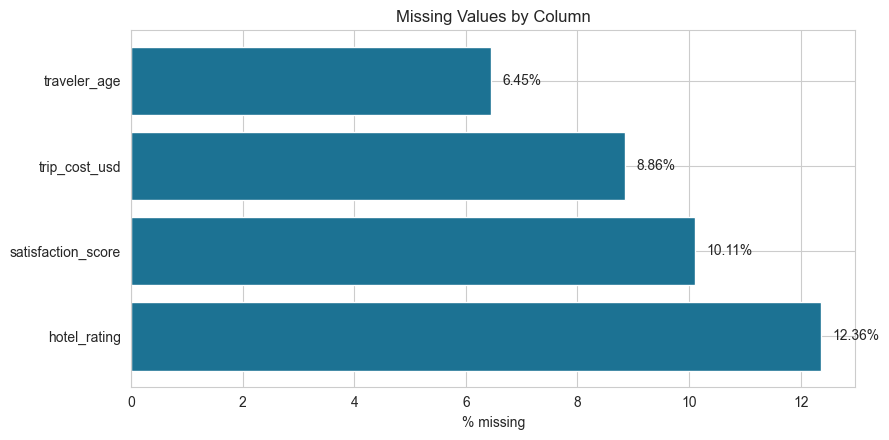

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
missing_only = missing_summary[missing_summary["missing_count"] > 0]
ax.barh(missing_only.index, missing_only["missing_pct"], color="#1C7293")
ax.set_xlabel("% missing")
ax.set_title("Missing Values by Column")
for i, v in enumerate(missing_only["missing_pct"]):
    ax.text(v + 0.2, i, f"{v}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

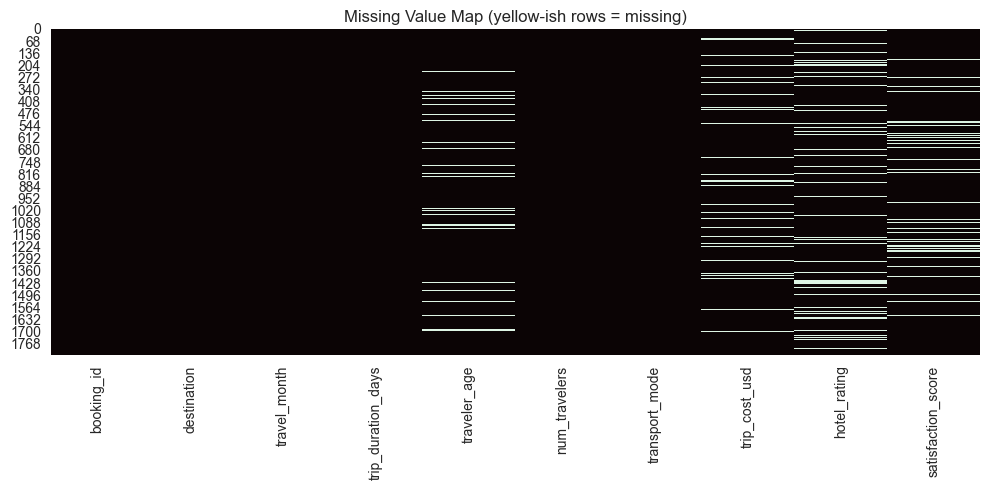

In [12]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="mako")
plt.title("Missing Value Map (yellow-ish rows = missing)")
plt.tight_layout()
plt.show()

### 🤔 Question 2

Based on the missing-value summary above:

**Which single column has the highest percentage of missing values, and roughly what percentage is it?**

Try to answer using code before revealing the solution.

In [13]:
# Your answer here


---
## 4. Handling Missing Values

There's no single "correct" way to deal with missing data — the right approach depends on **how much** is missing, the column's **data type**, and **why** it might be missing. We'll cover the most common strategies:

| Strategy | Function | When to use it |
|---|---|---|
| Drop rows | `df.dropna()` | Missingness is rare and rows are expendable |
| Drop columns | `df.drop(columns=...)` | A column is mostly missing (e.g. >50%) |
| Mean/median imputation | `df['col'].fillna(df['col'].mean())` | Numeric column, roughly symmetric/skewed distribution |
| Mode imputation | `df['col'].fillna(df['col'].mode()[0])` | Categorical column |
| Forward/backward fill | `df['col'].ffill()` / `.bfill()` | Ordered/time-series data |
| Interpolation | `df['col'].interpolate()` | Numeric, roughly continuous trend |
| Flag + impute | Add a `col_was_missing` indicator, then impute | When missingness itself might be predictive |

We'll keep the original `df` intact and build a cleaned copy, `df_clean`, so you can always compare before/after.

In [15]:
df_clean = df.copy()

# --- 1) traveler_age: numeric, roughly symmetric -> impute with the median ---
age_median = df_clean["traveler_age"].median()
df_clean["traveler_age"] = df_clean["traveler_age"].fillna(age_median)
print(f"traveler_age -> filled with median: {age_median}")

traveler_age -> filled with median: 38.0


In [16]:
# --- 2) trip_cost_usd: numeric, right-skewed (cost) -> impute with the median ---
cost_median = df_clean["trip_cost_usd"].median()
df_clean["trip_cost_usd"] = df_clean["trip_cost_usd"].fillna(cost_median)
print(f"trip_cost_usd -> filled with median: {cost_median}")

trip_cost_usd -> filled with median: 2184.38


In [17]:
# --- 3) hotel_rating: discrete ordinal scale -> impute with the mode (most common rating) ---
rating_mode = df_clean["hotel_rating"].mode()[0]
df_clean["hotel_rating"] = df_clean["hotel_rating"].fillna(rating_mode)
print(f"hotel_rating -> filled with mode: {rating_mode}")

hotel_rating -> filled with mode: 4.0


In [18]:
# --- 4) satisfaction_score: keep a missingness flag, THEN impute with the median ---
df_clean["satisfaction_missing_flag"] = df["satisfaction_score"].isnull().astype(int)
satisfaction_median = df_clean["satisfaction_score"].median()
df_clean["satisfaction_score"] = df_clean["satisfaction_score"].fillna(satisfaction_median)
print(f"satisfaction_score -> filled with median: {satisfaction_median}")
print("Added indicator column: 'satisfaction_missing_flag'")

satisfaction_score -> filled with median: 3.0
Added indicator column: 'satisfaction_missing_flag'


In [19]:
print("Missing values remaining in df_clean:")
df_clean.isnull().sum()

Missing values remaining in df_clean:


booking_id                   0
destination                  0
travel_month                 0
trip_duration_days           0
traveler_age                 0
num_travelers                0
transport_mode               0
trip_cost_usd                0
hotel_rating                 0
satisfaction_score           0
satisfaction_missing_flag    0
dtype: int64

### 🤔 Question 3

Suppose instead of imputing, you had simply run `df.dropna()` on the **original** `df`.

**Roughly how many rows would you expect to lose, and why is that risky here?**

Think it through, then try it below.

In [20]:
# Your answer here — try df.dropna() and compare row counts


---
## 5. Univariate Analysis

With a clean dataset (`df_clean`), we can now look at each variable on its own — its distribution, spread, and most common values.

In [22]:
df_clean["destination"].value_counts()

destination
Paris        286
Bali         221
New York     179
Tokyo        168
Rome         166
Sydney       163
Bangkok      147
Dubai        119
Barcelona    118
Cape Town    106
Prague        81
Lisbon        75
Name: count, dtype: int64

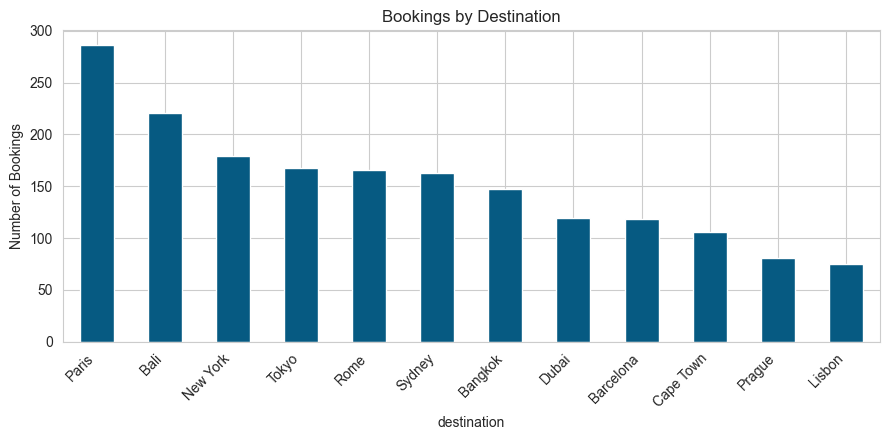

In [23]:
plt.figure(figsize=(9, 4.5))
df_clean["destination"].value_counts().plot(kind="bar", color="#065A82")
plt.title("Bookings by Destination")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [24]:
df_clean[["trip_duration_days", "traveler_age", "trip_cost_usd", "hotel_rating", "satisfaction_score"]].describe().T

,count,mean,std,min,25%,50%,75%,max
trip_duration_days,1829.0,11.369054,5.389931,2.00,7.00,12.00,16.0,20.00
traveler_age,1829.0,38.114817,11.446524,18.00,30.00,38.00,46.0,79.00
trip_cost_usd,1829.0,2596.883253,1775.321968,198.63,1370.77,2184.38,3389.2,11355.83
hotel_rating,1829.0,3.656370,0.818040,1.00,3.00,4.00,4.0,5.00
satisfaction_score,1829.0,3.000219,0.906933,1.00,2.40,3.00,3.6,5.00


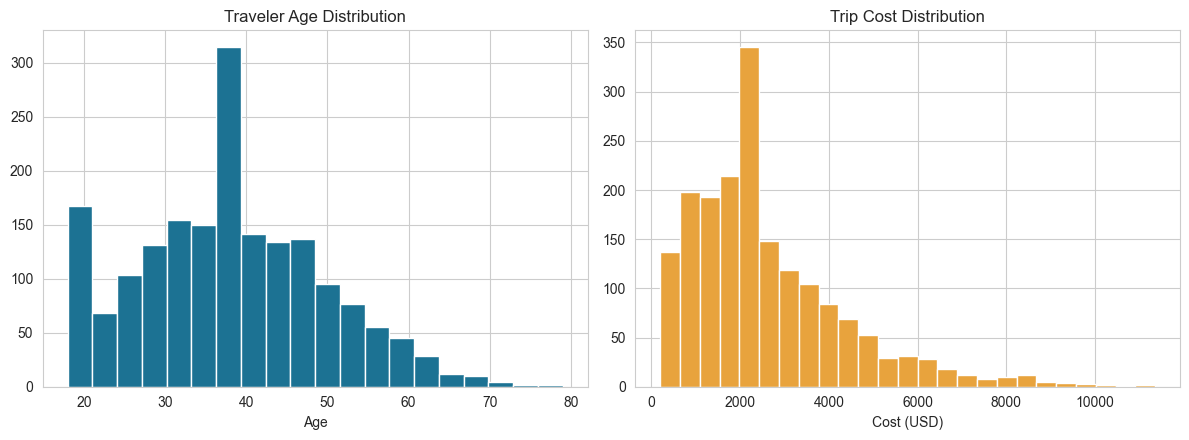

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df_clean["traveler_age"], bins=20, color="#1C7293", edgecolor="white")
axes[0].set_title("Traveler Age Distribution")
axes[0].set_xlabel("Age")

axes[1].hist(df_clean["trip_cost_usd"], bins=25, color="#E8A33D", edgecolor="white")
axes[1].set_title("Trip Cost Distribution")
axes[1].set_xlabel("Cost (USD)")
plt.tight_layout()
plt.show()

### 🤔 Question 4

**Which `transport_mode` is the most frequently used across all bookings, and what share of bookings does it represent?**

Try computing this yourself first.

In [26]:
# Your answer here


`Flight` is the most common transport mode (roughly 55% of bookings, matching how we generated the data) — unsurprising for a dataset spanning international destinations like Bali, Tokyo, and Cape Town.

---
## 6. Bivariate & Multivariate Analysis

Now we look at **relationships between variables** — does trip cost vary by destination? Does hotel rating relate to satisfaction?

In [28]:
avg_cost_by_dest = df_clean.groupby("destination")["trip_cost_usd"].mean().sort_values(ascending=False).round(2)
avg_cost_by_dest

destination
New York     3073.08
Sydney       2791.59
Paris        2670.63
Barcelona    2623.69
Dubai        2594.28
Bangkok      2568.85
Rome         2494.64
Bali         2464.66
Prague       2411.04
Lisbon       2410.43
Tokyo        2379.54
Cape Town    2360.50
Name: trip_cost_usd, dtype: float64

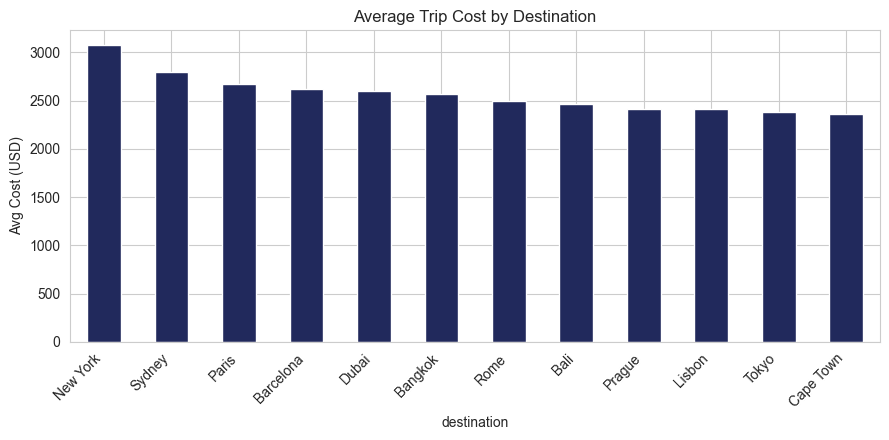

In [29]:
plt.figure(figsize=(9, 4.5))
avg_cost_by_dest.plot(kind="bar", color="#21295C")
plt.title("Average Trip Cost by Destination")
plt.ylabel("Avg Cost (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [30]:
numeric_cols = ["trip_duration_days", "traveler_age", "num_travelers",
                "trip_cost_usd", "hotel_rating", "satisfaction_score"]
corr_matrix = df_clean[numeric_cols].corr().round(2)
corr_matrix

,trip_duration_days,traveler_age,num_travelers,trip_cost_usd,hotel_rating,satisfaction_score
trip_duration_days,1.00,-0.01,0.02,0.64,-0.01,0.01
traveler_age,-0.01,1.00,-0.01,0.00,0.02,0.02
num_travelers,0.02,-0.01,1.00,0.62,-0.01,-0.01
trip_cost_usd,0.64,0.00,0.62,1.00,-0.01,-0.00
hotel_rating,-0.01,0.02,-0.01,-0.01,1.00,0.51
satisfaction_score,0.01,0.02,-0.01,-0.00,0.51,1.00


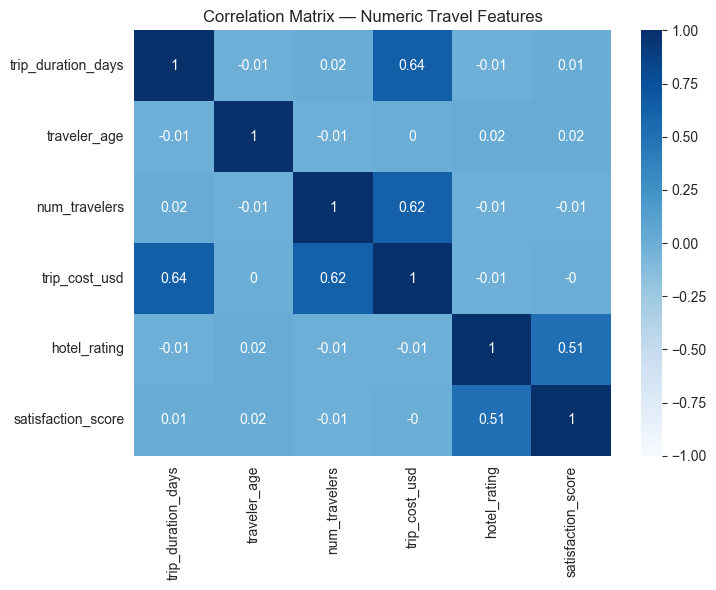

In [31]:
plt.figure(figsize=(7.5, 6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation Matrix — Numeric Travel Features")
plt.tight_layout()
plt.show()

In [32]:
pivot = df_clean.pivot_table(index="transport_mode", columns="num_travelers",
                              values="trip_cost_usd", aggfunc="mean").round(0)
pivot

num_travelers,1,2,3,4,5,6
transport_mode,,,,,,
Bus,1297.0,2430.0,2934.0,3609.0,3813.0,4346.0
Car,1385.0,2259.0,2940.0,4084.0,4184.0,5059.0
Flight,1497.0,2344.0,3027.0,3996.0,4736.0,6083.0
Train,1481.0,2330.0,3013.0,3949.0,5191.0,4593.0


### 🤔 Question 5

Looking at the correlation matrix above:

**Which two numeric columns are most strongly (positively) correlated, and does that match how we generated the data?**

Try it yourself before checking below.

In [33]:
# Your answer here


---
## 7. Visualization & Summary Insights

Let's finish with a couple of richer visuals that combine several variables at once.

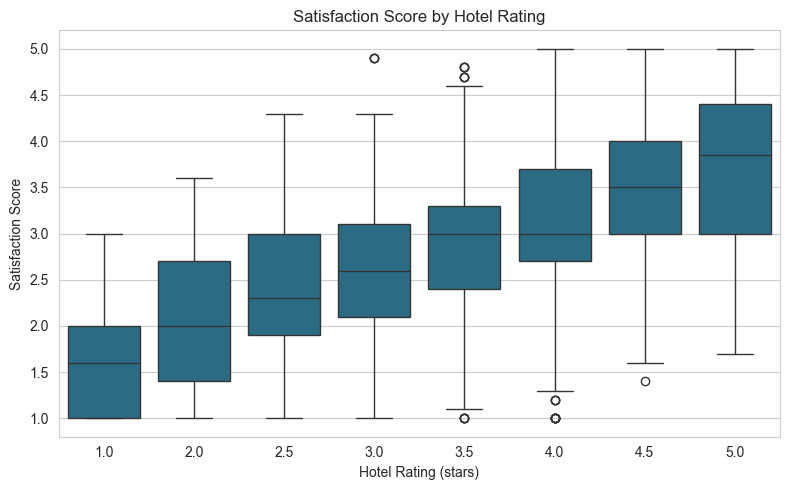

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="hotel_rating", y="satisfaction_score", color="#1C7293")
plt.title("Satisfaction Score by Hotel Rating")
plt.xlabel("Hotel Rating (stars)")
plt.ylabel("Satisfaction Score")
plt.tight_layout()
plt.show()

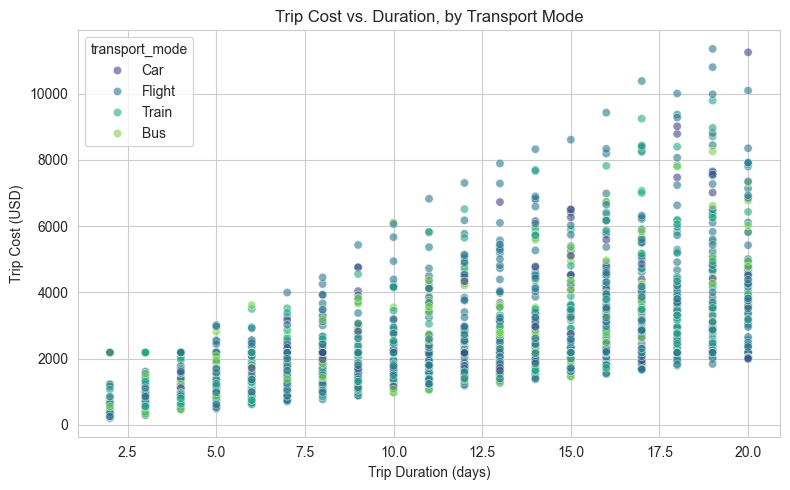

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="trip_duration_days", y="trip_cost_usd",
                 hue="transport_mode", alpha=0.6, palette="viridis")
plt.title("Trip Cost vs. Duration, by Transport Mode")
plt.xlabel("Trip Duration (days)")
plt.ylabel("Trip Cost (USD)")
plt.tight_layout()
plt.show()

### Question 6

**Based on the boxplot above, does a higher hotel rating visually appear to correspond to a higher median satisfaction score?**

Write your observation in the markdown cell below, then compare with the solution.

In [37]:
# Your answer here (or write your observation as a comment)


---
## 8. Summary & Key Takeaways

| Stage | What we did |
|---|---|
| **Generate** | Built a synthetic 1,829 × 10 travel dataset with realistic missing values |
| **Inspect** | Used `shape`, `info()`, `describe()` to understand structure |
| **Detect missing data** | Quantified and visualized missingness with `isnull()`, bar charts, and a heatmap |
| **Handle missing data** | Applied median/mode imputation column-by-column, and preserved a missingness flag where it mattered |
| **Univariate analysis** | Explored individual columns via `value_counts()`, histograms, and `describe()` |
| **Bivariate/multivariate analysis** | Used `groupby()`, `corr()`, and `pivot_table()` to study relationships |
| **Visualization** | Combined variables in boxplots and scatterplots to confirm patterns |

**Core lesson:** always understand *why* data is missing and *how much* is missing before choosing a strategy — dropping rows is the simplest option, but usually the most wasteful. Imputation, when done thoughtfully per-column, preserves your dataset while still handling the gap responsibly.
